## Project: Mapping the Potential Destructive Power of Wildfires Using Machine Learning

### Module 3: *Variable Selection*

---
### Contents  
- 1. *Load Data*
- 2. *Water Demand Variables*
- 3. *Water Supply Variables*
- 4. *Geographic, Social, and Temporal Variables*
- 5. *Filter and Export File*
---
### Notes
---
### Inputs
- `model_fire_pop_income.csv` cleaned weather data joined with cleaned fire damage dataset
- `details.csv` saved details associated with main dataset
---
### Outputs 
- `trimmed.csv` - trimmed weather and fire dataset
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

# Function to print a grid of kde plots in consistent format, adjusts columns and rows accordingly
from src.plot_utils import grid_kde

# Function to print a custom format correlation heatmap
from src.plot_utils import correlation_map

# Function to create all second degree interactions possible in a dataset, then name these terms
# in the format of feature1_x_feature2. Returns dataframe of interactions.
from src.data_utils import create_2nd_degree_interactions

# A space saving function to rank interactions
from src.data_utils import rank_interactions_by_correlation

# Function to calculate dryness index and return a dataframe
from src.data_utils import calculate_dryness_index

---
### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize

# Modeling prep
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# Set consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---

## 1. Loading Data

This section visualizes key environmental variables to assess their relationships with wildfire severity categories. Based on the `Categorical Index`, we explore how different weather features interact and influence fire risk.

In [ ]:
# Copy details for use later in the project
details = pd.read_csv("../data/processed/details.csv")
filtered = pd.read_csv('../data/processed/model_fire_pop_income.csv')

In [ ]:
filtered

Index(['Sample_ID', 'Date', 'Sample_Elevation', 'Region_ID', 'ETo (in)',
       'Precip (in)', 'Sol Rad (Ly/day)', 'Avg Vap Pres (mBars)',
       'Max Air Temp (F)', 'Min Air Temp (F)', 'Avg Air Temp (F)',
       'Max Rel Hum (%)', 'Min Rel Hum (%)', 'Avg Rel Hum (%)',
       'Dew Point (F)', 'Avg Wind Speed (mph)', 'Wind Run (miles)',
       'Avg Soil Temp (F)', 'Season', 'Total Population', 'density',
       'Mean Income', 'Target'],
      dtype='object')

> ### Note  
> To reduce dataset size and simplify analysis, the following variables will be dropped:  
> - Dropped **Min** and **Max Air Temperature**, retained **Average Air Temperature**  
> - Dropped **Min** and **Max Relative Humidity**, retained **Average Relative Humidity**

In [ ]:
## Master drop list for application at end of file
drop = ['Max Air Temp (F)','Min Air Temp (F)','Max Rel Hum (%)','Min Rel Hum (%)']

## 2. DIrect Water Demand Indicators

### 2.1 Water Demand Distribution Analysis

- `ETo (in)` - Evapotranspiration is a measure of how much water is lost to the atmosphere
- `Sol Rad (Ly/day)` - A measure of sunlight the soil has recieved in a day
- `Avg Air Temp (F)`- Elevated air temperatures increase vegetation dryness and boost fire intensity  
- `Avg Wind Speed (mph)` - Stronger winds accelerate fire spread and push embers further, creating spot fires 
- `Avg Soil Temp (F)` - Warm soils suggest extended dry periods; contribute to desiccated fuel beds  
- `Wind Run (miles)` - Total wind movement over time; influences how far and fast fires can travel

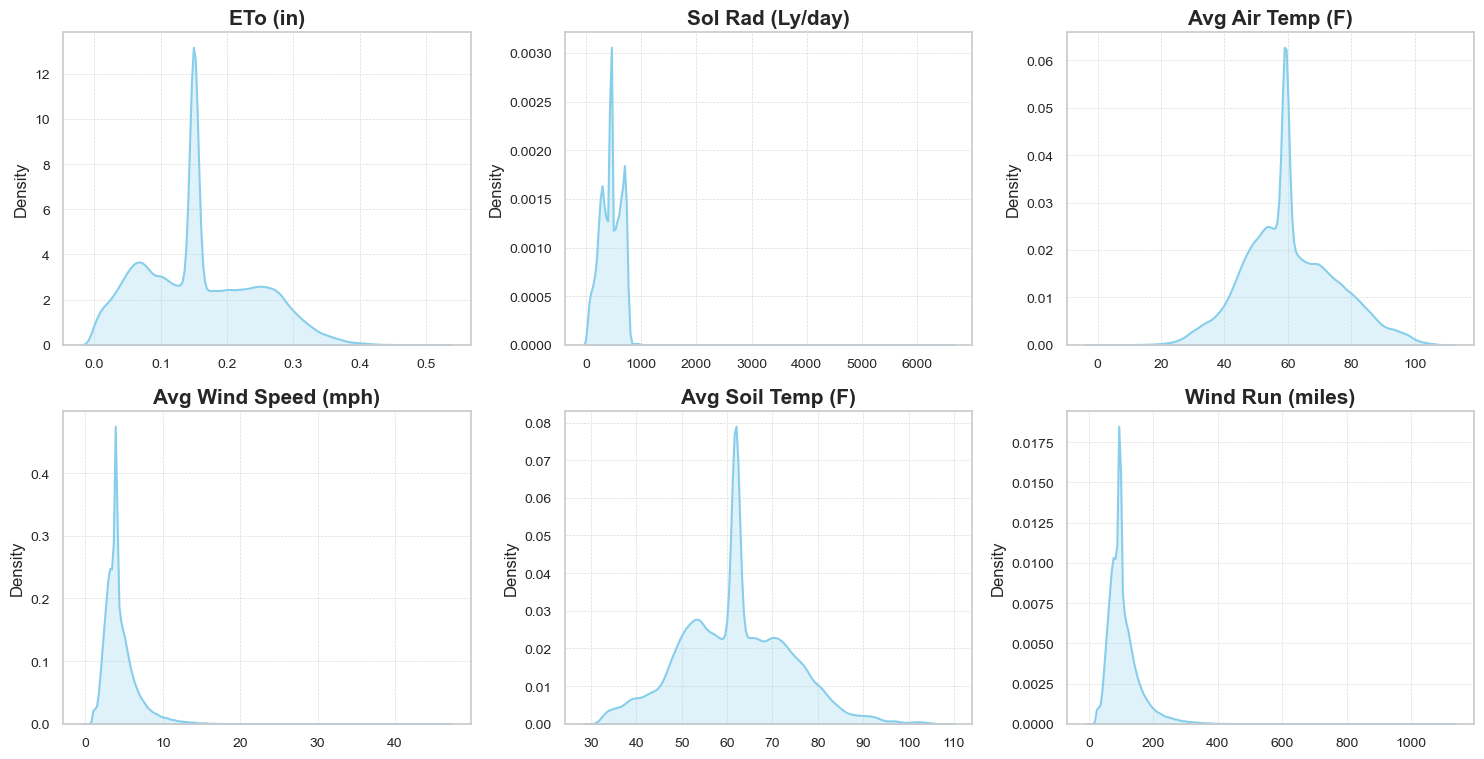

In [ ]:
water_demand = ['ETo (in)', 'Sol Rad (Ly/day)', 'Avg Air Temp (F)', 'Avg Wind Speed (mph)', 
                'Avg Soil Temp (F)','Wind Run (miles)','Target']

grid_kde(filtered[water_demand].drop(columns='Target'))

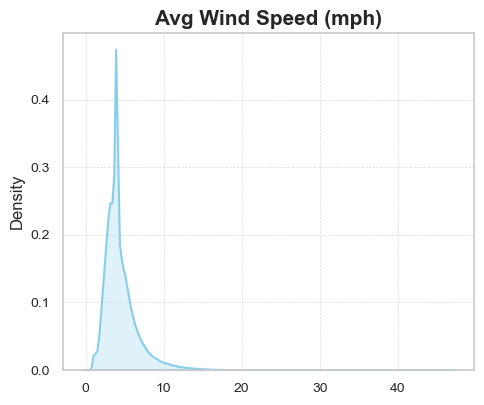

In [ ]:
filtered['Avg Wind Speed (mph)'] = filtered['Avg Wind Speed (mph)'].clip(upper=30)

grid_kde(filtered[['Avg Wind Speed (mph)']])

### 2.2 Water Demand Correlation analysis

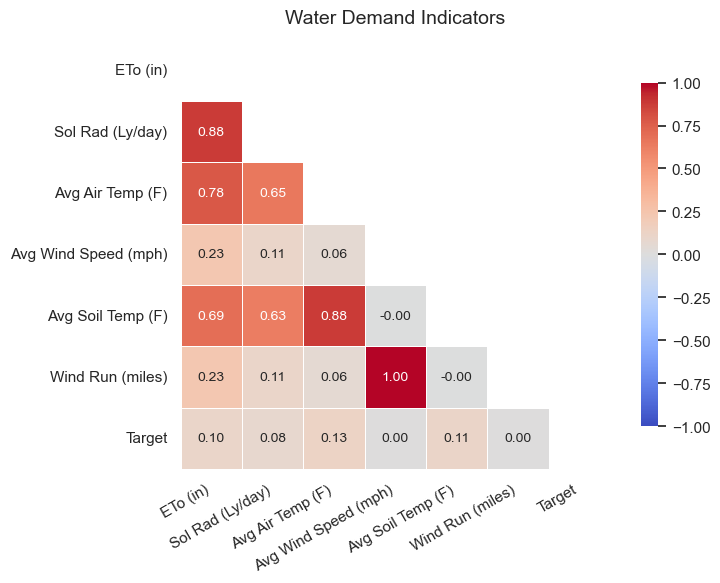

In [10]:
correlation_map(filtered[water_demand],'Water Demand Indicators')

#### Key Insights: Water Demand Variables

- **Evapotranspiration (ETo)** and **Solar Radiation** show a strong positive correlation, indicating shared influence from sunlight and temperature — both crucial in assessing vegetation moisture loss.
  
- **Dew Point** and **Vapor Pressure** are highly correlated, suggesting they provide overlapping information. These variables reflect atmospheric moisture content and may be redundant in modeling.

- Together, these indicators are effective in representing **vegetation dryness**, a critical factor in estimating wildfire ignition and spread potential.

- `ETO` and `Avg Vapor Pressure` are more correllated with target


### 2.3 Water Demand Colinearity analysis

In [ ]:
sns.scatterplot(
    x='ETo (in)', y='Sol Rad (Ly/day)', hue='Adjusted Value', data=filtered, palette='viridis', alpha=0.7
)

<Axes: xlabel='Avg Wind Speed (mph)', ylabel='Wind Run (miles)'>

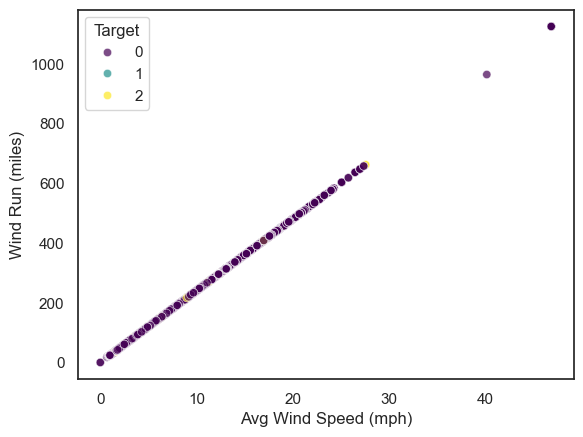

In [11]:
sns.scatterplot(
    x='Avg Wind Speed (mph)', y='Wind Run (miles)', hue='Target', data=filtered, palette='viridis', alpha=0.7
)

<Axes: xlabel='Avg Soil Temp (F)', ylabel='Avg Air Temp (F)'>

C:\Users\dusti\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


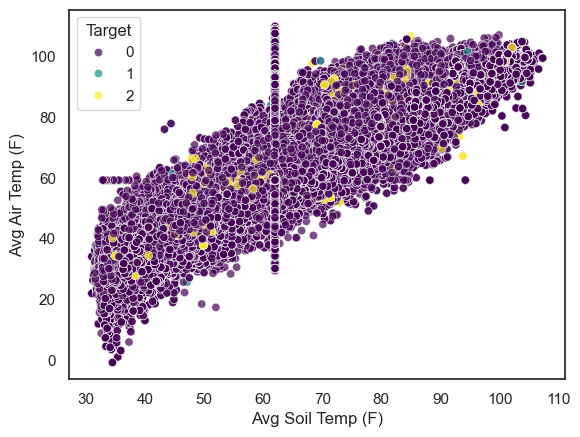

In [12]:
sns.scatterplot(
    x='Avg Soil Temp (F)', y='Avg Air Temp (F)', hue='Target', data=filtered, palette='viridis', alpha=0.7
)

### 2.4 Key Findings - Water Demand Indicators

- **Evapotranspiration (ETo)** and **Solar Radiation** showed a **strong positive correlation**, indicating that days with high solar energy also tend to have greater evaporative demand. This aligns with meteorological understanding and highlights both as valuable indicators of fuel dryness.
- **Average Wind Speed (mph)** and **Wind Run (miles)** show direct correlation, drop wind run and keep wind speed

In [ ]:
drop.extend(['Wind Run (miles)'])
drop

## 3. Water Supply Indicators

### 3.1 Water Supply Distribution Analysis

- `Precip (in)` - Rainfall reduces wildfire risk by moistening vegetation and fuels; prolonged dryness increases flammability
- `Avg Rel Hum (%)` - Average relative humidity reflects how saturated the air is; lower values dry out fuels and promote ignition
- `Avg Vap Pres (mBars)` - Vapor pressure indicates moisture content in the air; lower pressure signals drier conditions favorable for fire spread  
- `Dew Point (F)` - The temperature at which air becomes saturated; lower dew points mean drier air, increasing fire potential 

In [ ]:
water_supply = ['Precip (in)', 'Avg Rel Hum (%)', 'Avg Vap Pres (mBars)', 'Dew Point (F)', 'Target']
grid_kde(filtered[water_supply].drop(columns='Target'))

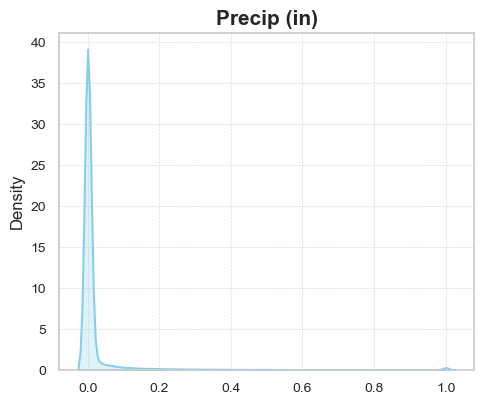

In [ ]:
filtered['Precip (in)'] = filtered['Precip (in)'].clip(upper=1)
grid_kde(filtered[['Precip (in)']])

### 3.2 Water Supply Correlation Analysis

- **Inverse Relationship with Fire Severity**  
  Both precipitation and relative humidity indicators are **negatively correlated** with the categorical fire risk index. This aligns with domain expectations—**drier and less humid conditions correspond to higher wildfire severity**.

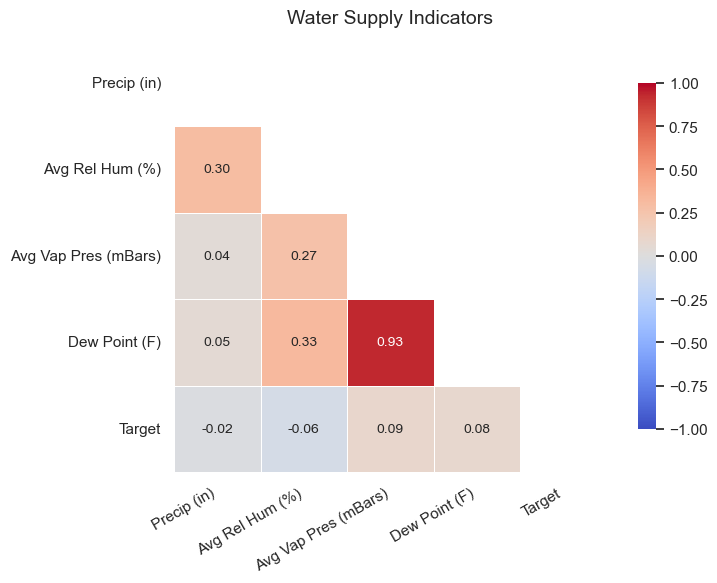

In [17]:
correlation_map(filtered[water_supply],'Water Supply Indicators')

### 3.3 Water Supply Colinearity Analysis

Drop `Dew Point (F)` due to **colinearity** with `Avg Vap Pres (mBars)` and less correlation with the target index

<Axes: xlabel='Avg Vap Pres (mBars)', ylabel='Dew Point (F)'>

C:\Users\dusti\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\dusti\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


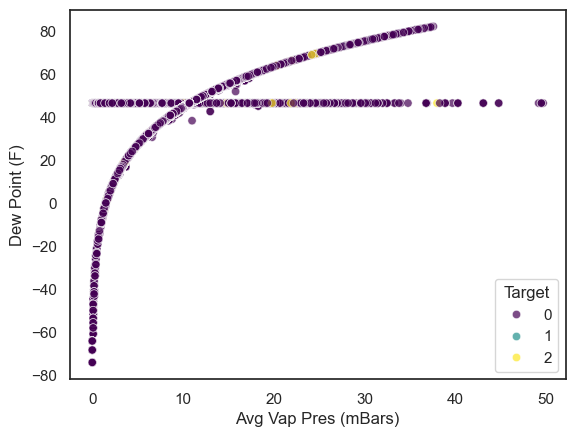

In [18]:
sns.scatterplot(
    x='Avg Vap Pres (mBars)', y='Dew Point (F)', hue='Target', data=filtered, palette='viridis', alpha=0.7
)

In [ ]:
drop.extend(['Dew Point (F)'])

['Max Air Temp (F)',
 'Min Air Temp (F)',
 'Max Rel Hum (%)',
 'Min Rel Hum (%)',
 'Wind Run (miles)',
 'Dew Point (F)']

### 3.4 Water Supply Key Findings

## 4. Geographic, Social, and Temporal Variables
- Geographic, Social, and Temporal Variables

### 4.1 Geographic, Social, and Temporal Variables Distribution Analysis
- Social Indicators - `Total Population`, `Mean Income`, `density`
- Geographic Indicators - `Elevation`,`Region`
- Temporal Indicators - `Season`

In [ ]:
social = ['Total Population', 'Mean Income', 'density', 'Season', 
                'Sample_Elevation','Region_ID','Target']
grid_kde(filtered[social].drop(columns='Target'))

### 4.2 Geographic, Social, and Temporal Variables Correlation Analysis

In [ ]:
correlation_map(filtered[social],'Geographic, Social, and Temporal Variables')

### 4.3 Geographic, Social, and Temporal Variables Colinearity Analysis

### 4.4 Geographic, Social, and Temporal Variables Key Findings

## 5. Filter and Export 

In [20]:
selected = filtered.drop(columns = drop)
selected

,Sample_ID,Date,Sample_Elevation,Region_ID,ETo (in),Precip (in),Sol Rad (Ly/day),Avg Vap Pres (mBars),Avg Air Temp (F),Avg Rel Hum (%),Avg Wind Speed (mph),Avg Soil Temp (F),Season,Total Population,density,Mean Income,Target
0,1,2018-01-01,36.609302,7,0.05,0.02,230.0,14.3,55.4,96.0,3.1,56.8,0,3269973,777.337917,111241,0
1,33,2018-01-01,1096.443481,5,0.10,0.00,260.0,4.1,51.9,31.0,4.1,53.8,0,441257,161.331803,111731,0
2,144,2018-01-01,1039.047485,1,0.06,0.00,228.0,8.4,48.9,71.0,3.4,47.0,0,64896,22.000807,74237,0
3,32,2018-01-01,288.821625,5,0.15,0.00,449.0,9.5,59.2,55.0,3.9,61.8,0,441257,161.331803,111731,0
4,145,2018-01-01,1615.276733,2,0.05,0.00,222.0,8.8,47.1,80.0,1.8,45.9,0,207172,126.597656,79233,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447775,52,2025-01-23,925.951294,6,0.10,0.00,347.0,1.5,43.7,16.0,4.9,40.6,0,2195611,109.468892,85327,0
447776,124,2025-01-23,473.016693,1,0.07,0.00,276.0,6.2,45.2,60.0,2.5,46.0,0,89108,25.413394,74102,0
447777,51,2025-01-23,1046.279663,6,0.10,0.00,347.0,1.5,43.7,16.0,4.9,40.6,0,2195611,109.468892,85327,0
447778,50,2025-01-23,956.628479,4,0.15,0.00,333.0,1.2,39.9,14.0,1.8,49.7,0,913820,112.374445,75161,0


In [ ]:
selected.to_csv('../data/processed/trimmed.csv', index=False)
print("All datasets saved successfully to ../data/processed/")